# 3. Mushroom foraging

The [mushroom dataset](https://www.kaggle.com/datasets/dhinaharp/mushroom-dataset) contains data about approximately 60000 mushrooms, and your task is to classify them as either edible or poisonous. You can read about the features [here](https://www.kaggle.com/datasets/uciml/mushroom-classification) and import the data using:

In [3]:
import pandas as pd
pd.set_option('display.max_columns', 1000)
df = pd.read_csv('secondary_data.csv', delimiter = ';')
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,17.09,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,18.19,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,17.74,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,15.98,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,17.20,s,y,w,u,w,t,p,NaN,d,w


It's up to you how you approach this data, but at a minimum, your analysis should include:

* Informed **data preparation**.
* Use the **logistic regression**.
* Three different **validation methodologies** used to tune hyperparameters, discussing the pros and cons of each.
* **Confusion matrices** for your models, and associated comments.
 * Evaluate your models using the following metrics and provide associated comments for each:
   - **ROC curve**
   - **precision-recall curve**
   - **F1 score**
   - **accuracy**
   - **recall**
   - **precision**
* A discussion of which **performance metric** is most relevant for the evaluation of your models.

Please remember to provide associated comments for each metric; it is not enough to just provide the metric values.

In [10]:
from sklearn.model_selection import train_test_split

# remove target to be predicted from the data set
X = df.drop(columns=["class"])
y = df["class"]

X.head()

,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,15.26,x,g,o,f,e,NaN,w,16.95,17.09,s,y,w,u,w,t,g,NaN,d,w
1,16.60,x,g,o,f,e,NaN,w,17.99,18.19,s,y,w,u,w,t,g,NaN,d,u
2,14.07,x,g,o,f,e,NaN,w,17.80,17.74,s,y,w,u,w,t,g,NaN,d,w
3,14.17,f,h,e,f,e,NaN,w,15.77,15.98,s,y,w,u,w,t,p,NaN,d,w
4,14.64,x,h,o,f,e,NaN,w,16.53,17.20,s,y,w,u,w,t,p,NaN,d,w


In [11]:
# drop the NaN columns
X = X.drop(columns=["gill-spacing", "spore-print-color"])
X.head()

,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,habitat,season
0,15.26,x,g,o,f,e,w,16.95,17.09,s,y,w,u,w,t,g,d,w
1,16.60,x,g,o,f,e,w,17.99,18.19,s,y,w,u,w,t,g,d,u
2,14.07,x,g,o,f,e,w,17.80,17.74,s,y,w,u,w,t,g,d,w
3,14.17,f,h,e,f,e,w,15.77,15.98,s,y,w,u,w,t,p,d,w
4,14.64,x,h,o,f,e,w,16.53,17.20,s,y,w,u,w,t,p,d,w


Number data points training set: 39084
Number data points validation set: 9771
Number data points test set: 12214


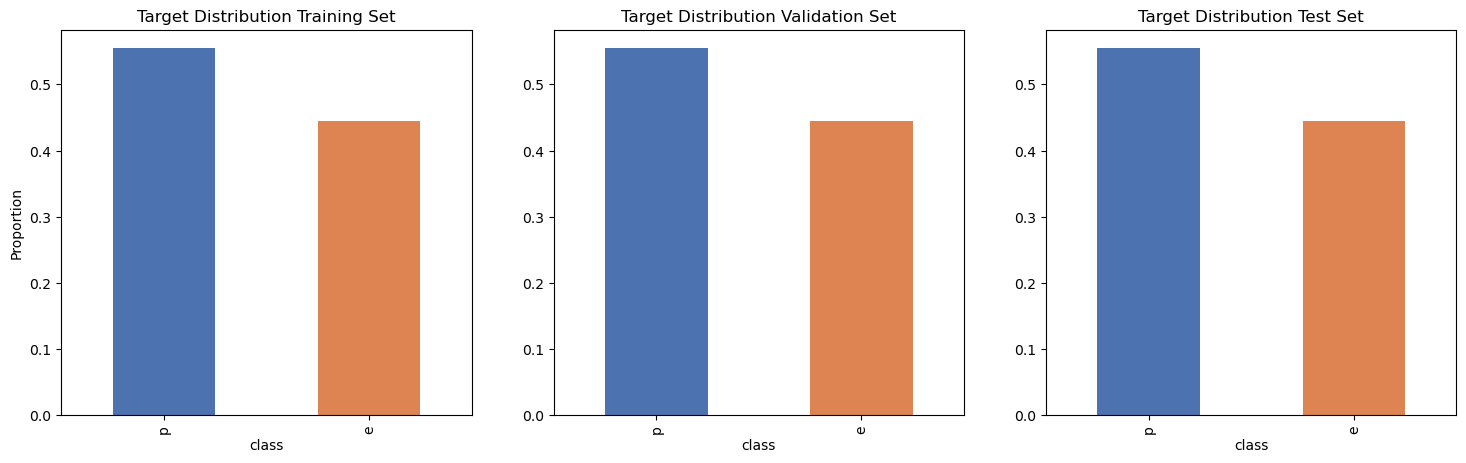

In [12]:
#convert text categories with 1 and 0 s (One hot encoding)
X_encoded = pd.get_dummies(X, drop_first=True)

# first split: train the model tradicional 80/20, Stra.. to make sure the predict valeu are at the same proportion
X_train_val, X_test, y_train_val, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42,stratify=y)

# second slip: train/validation withe the remainns data
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val)

print(f"Number data points training set: {len(X_train)}")
print(f"Number data points validation set: {len(X_val)}")
print(f"Number data points test set: {len(X_test)}")


import matplotlib.pyplot as plt


plt.figure(figsize=(18, 5))


plt.subplot(1, 3, 1)
y_train.value_counts(normalize=True).plot(kind="bar", color=['#4C72B0', '#DD8452'])
plt.title("Target Distribution Training Set")
plt.ylabel("Proportion")



plt.subplot(1, 3, 2)
y_val.value_counts(normalize=True).plot(kind="bar", color=['#4C72B0', '#DD8452'])
plt.title("Target Distribution Validation Set")


plt.subplot(1, 3, 3)
y_test.value_counts(normalize=True).plot(kind="bar", color=['#4C72B0', '#DD8452'])
plt.title("Target Distribution Test Set")


plt.show()

--- Hyperparameter Tuning (Validation Phase) ---
Model with C=0.01 -> Validation Accuracy: 0.8161
Model with C=0.1 -> Validation Accuracy: 0.8349
Model with C=1 -> Validation Accuracy: 0.8361
Model with C=10 -> Validation Accuracy: 0.8359
Model with C=100 -> Validation Accuracy: 0.8354

>> Best hyperparameter selected: C=1 <<

--- Final Test Set Performance ---
Accuracy:  0.84
Precision: 0.85
Recall:    0.85
F1 score:  0.85



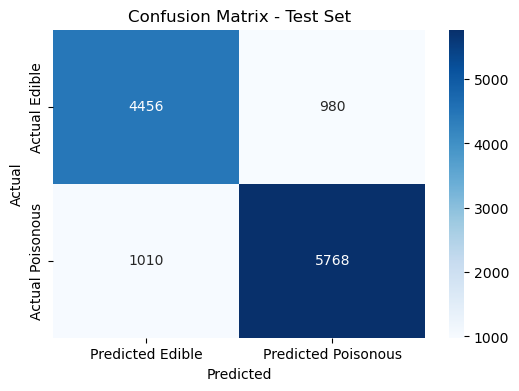

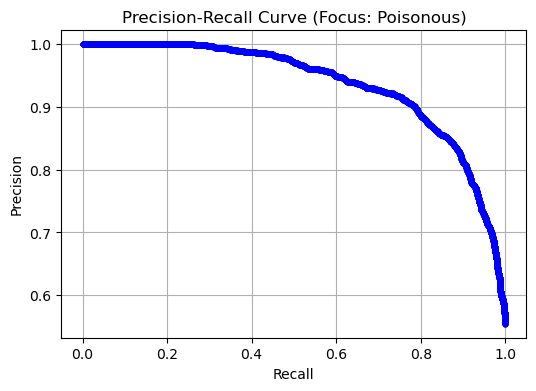

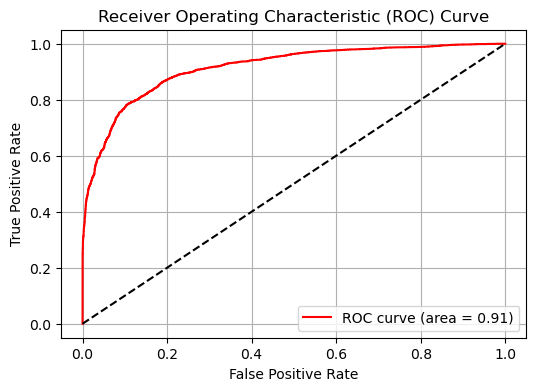

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt


c_values = [0.01, 0.1, 1, 10, 100]
best_c = None
best_val_accuracy = 0

print("--- Hyperparameter Tuning (Validation Phase) ---")
for c in c_values:
    # Initialize the model with C value
    log_reg = LogisticRegression(C=c, max_iter=2000, random_state=42)
    
    # Train on  training subset
    log_reg.fit(X_train, y_train)
    
    # Evaluate on  validation subset
    val_acc = log_reg.score(X_val, y_val)
    print(f"Model with C={c} -> Validation Accuracy: {val_acc:.4f}")
    

    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        best_c = c

print(f"\n>> Best hyperparameter selected: C={best_c} <<\n")


# Re-train the final model using the best 'C' on the combined Train+Val data
final_model = LogisticRegression(C=best_c, max_iter=2000, random_state=42)
final_model.fit(X_train_val, y_train_val)

# Predict on the completely unseen Test set
y_test_pred = final_model.predict(X_test)

# Get probabilities for the ROC and PR curves
y_test_prob = final_model.predict_proba(X_test)[:, 1] 


test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, pos_label='p')
test_recall = recall_score(y_test, y_test_pred, pos_label='p')
test_f1 = f1_score(y_test, y_test_pred, pos_label='p')

print("--- Final Test Set Performance ---")
print(f"Accuracy:  {test_accuracy:.2f}")
print(f"Precision: {test_precision:.2f}")
print(f"Recall:    {test_recall:.2f}")
print(f"F1 score:  {test_f1:.2f}\n")


# A. Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred, labels=['e', 'p'])
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Predicted Edible", "Predicted Poisonous"], 
            yticklabels=["Actual Edible", "Actual Poisonous"])
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# B. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_test_prob, pos_label='p')
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, marker=".", color="blue")
plt.title("Precision-Recall Curve (Focus: Poisonous)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.show()

# C. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_prob, pos_label='p')
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color="red", label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--") # Diagonal line for random chance
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.show()

- **Accuracy (0.85)**: while 85% is solid, accuracy trats all errors as equally bad, make it dangerous to rely exculsively on itself.
- **Precision (0.86)**: positive predictive value, every time the model precidcts whether the shrooms are edible or not it is right 86%, the other 14% are the false positives.
- **Recall (0.86)**: this measures how many of the actual poisonous shrooms were succfully identified, the rest are the shrooms that sliped thru the filter.
- **F1 Score (0.86)**: this is the mean between precision and recall, it show the model performance, by showing that it handles both false positives and false negatives relatively well.
- **ROC (AUC = 0.91)**: this is the representation of true positive rates against false positive accross different thressholds, AUC of 0.91 indicates execellent overall capacity to distinguish between edible and poisonous

### CONCLUSION 
For mushroom foraging, Recall is undoubtedly the most relevant performance metric. When dealing with potentially deadly fungi, we must optimize our model to minimize False Negatives.
- A False Positive means discarding a safe mushroom (low cost).
- A False Negative means eating a poisonous mushroom, which could be fatal (extreme cost).

better having a sensitive model high recall that over-warns us even if it sacrificies some precision.